# Random Forest Classification – Target Encoding for meat_type

**Goal:** Use target encoding to create smarter features that directly
capture the relationship between each feature value and the target
(`meat_type`).

**What is Target Encoding?**

Instead of using raw feature values (cut_quality = 1, 2, 3, 4, 5), we
replace each value with the **mean of the target** for that group.

Example for `cut_quality`:
- cut_quality 1 → mean meat_type of all rows where cut_quality=1 → 2.99
- cut_quality 5 → mean meat_type of all rows where cut_quality=5 → 2.96

If the mean is similar across all groups, the feature has no signal.
If the means differ, the encoding captures real patterns.

**Why it helps:**
- Converts categorical features into numbers the model can split on meaningfully
- A tree splitting on "cut_quality_encoded > 3.1" is splitting on "quality groups
  that tend to be higher meat types" — more informative than raw numbers

**Risk: Data Leakage**
Target encoding uses the target to create features. If done on the full
dataset, the model sees information it shouldn't. We prevent this by:
1. Computing encodings ONLY from the training set
2. Applying the same encodings to test and stress data

**Workflow:**
1. Load data, train/test split
2. Compute target encodings from training data
3. Apply encodings to train, test, and stress data
4. Train Random Forest on encoded features
5. Evaluate on internal test and stress test
6. Compare with all previous classification results


## Step 1 – Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

print("All imports successful.")


All imports successful.


## Step 2 – Load Data and Train/Test Split

In [2]:
df = pd.read_csv("meat_price_dataset.csv")

target_col = "meat_type"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Features: {feature_cols}")


Train: 960 rows | Test: 240 rows
Features: ['fat_content_pct', 'protein_pct', 'marbling_score', 'animal_age_months', 'storage_days', 'organic', 'cut_quality', 'price_eur_per_kg']


## Step 3 – Compute Target Encodings (from training data ONLY)

For each feature, we group by its values and calculate the **mean meat_type**
per group. This is our encoding lookup table.

We encode these features:
- `cut_quality` (1–5) — ordinal, might have hidden pattern with meat type
- `organic` (0/1) — binary, might differ by meat type
- `marbling_score` (1–10) — ordinal, marbling could relate to meat type
- `price_eur_per_kg` — continuous, so we **bin it first** then encode

Continuous features like `fat_content_pct` and `protein_pct` are already
numeric — target encoding adds the most value to categorical/ordinal features.


In [4]:
# Combine train features + target for encoding computation
train_df = X_train.copy()
train_df[target_col] = y_train.values

# --- Categorical / Ordinal features: direct target encoding ---
encode_cols = ["cut_quality", "organic", "marbling_score"]

encoding_maps = {}

print("=== Target Encoding Maps (from training data) ===")
for col in encode_cols:
    te_map = train_df.groupby(col)[target_col].mean()
    encoding_maps[col] = te_map
    print(f"{col}:")
    print(te_map.round(4))
    print()

# --- Price: bin into 5 groups, then target encode the bins ---
price_bins = pd.qcut(train_df["price_eur_per_kg"], q=5, labels=False)
train_df["price_bin"] = price_bins

price_te_map = train_df.groupby("price_bin")[target_col].mean()
encoding_maps["price_bin"] = price_te_map

# Also store the bin edges for applying to test/stress data
_, bin_edges = pd.qcut(train_df["price_eur_per_kg"], q=5, retbins=True)
bin_edges[0]  = -np.inf  # handle values below training min
bin_edges[-1] = np.inf   # handle values above training max

print("price_eur_per_kg (binned into 5 groups):")
print(price_te_map.round(4))
print(f"Bin edges: {[round(b, 2) for b in bin_edges]}")


=== Target Encoding Maps (from training data) ===
cut_quality:
cut_quality
1    2.9215
2    3.0284
3    3.0000
4    3.1343
5    2.9849
Name: meat_type, dtype: float64

organic:
organic
0    2.9242
1    3.1072
Name: meat_type, dtype: float64

marbling_score:
marbling_score
1     2.9748
2     3.0935
3     3.0526
4     2.9583
5     2.9111
6     3.0625
7     2.9080
8     2.9149
9     3.2841
10    3.0114
Name: meat_type, dtype: float64

price_eur_per_kg (binned into 5 groups):
price_bin
0    1.3886
1    2.0890
2    3.1510
3    3.8660
4    4.6000
Name: meat_type, dtype: float64
Bin edges: [np.float64(-inf), np.float64(15.59), np.float64(20.81), np.float64(25.89), np.float64(30.59), np.float64(inf)]


## Step 4 – Apply Target Encoding to All Datasets

We create new `_te` (target encoded) columns and keep the original
features too — the model can use both.


In [5]:
def apply_target_encoding(X_data, encoding_maps, bin_edges):
    """Apply precomputed target encodings to a dataset."""
    X_encoded = X_data.copy()
    
    # Encode categorical/ordinal features
    for col in ["cut_quality", "organic", "marbling_score"]:
        te_map = encoding_maps[col]
        # Map values; unseen values get the global mean
        global_mean = te_map.mean()
        X_encoded[f"{col}_te"] = X_data[col].map(te_map).fillna(global_mean)
    
    # Encode price bins
    price_bins = pd.cut(X_data["price_eur_per_kg"], bins=bin_edges, labels=False)
    te_map = encoding_maps["price_bin"]
    global_mean = te_map.mean()
    X_encoded["price_bin_te"] = price_bins.map(te_map).fillna(global_mean)
    
    return X_encoded

# Apply to train and test
X_train_te = apply_target_encoding(X_train, encoding_maps, bin_edges)
X_test_te  = apply_target_encoding(X_test, encoding_maps, bin_edges)

new_features = [c for c in X_train_te.columns if c not in X_train.columns]
print(f"New target-encoded features: {new_features}")
print(f"Total features: {X_train.shape[1]} original + {len(new_features)} encoded = {X_train_te.shape[1]}")
print(f"Sample of encoded train data:")
print(X_train_te[new_features].head(10).round(4))


New target-encoded features: ['cut_quality_te', 'organic_te', 'marbling_score_te', 'price_bin_te']
Total features: 8 original + 4 encoded = 12
Sample of encoded train data:
      cut_quality_te  organic_te  marbling_score_te  price_bin_te
318           3.0284      3.1072             2.9111        4.6000
876           2.9849      3.1072             2.9111        3.8660
571           2.9215      2.9242             2.9080        3.1510
195           3.0284      3.1072             2.9583        1.3886
164           3.0284      3.1072             3.0526        3.1510
65            3.1343      3.1072             3.0526        2.0890
1062          3.1343      2.9242             3.0114        1.3886
270           3.0284      3.1072             3.0625        1.3886
728           2.9849      3.1072             3.0935        3.8660
152           2.9849      3.1072             2.9080        4.6000


## Step 5 – Visualise: Do the Encodings Add Signal?

If the encoded features show different distributions per meat_type,
they carry useful signal for classification.


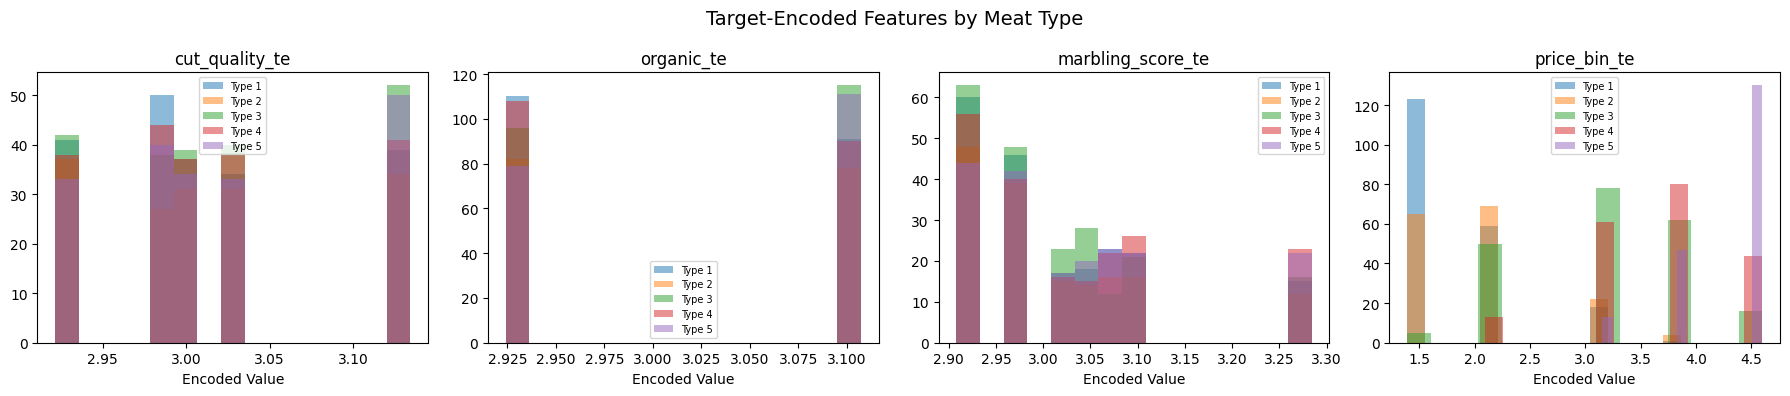

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

te_cols = ["cut_quality_te", "organic_te", "marbling_score_te", "price_bin_te"]

for ax, col in zip(axes, te_cols):
    for mt in sorted(y_train.unique()):
        mask = y_train == mt
        ax.hist(X_train_te.loc[mask.values, col], bins=15, alpha=0.5, label=f"Type {mt}")
    ax.set_title(col)
    ax.set_xlabel("Encoded Value")
    ax.legend(fontsize=7)

plt.suptitle("Target-Encoded Features by Meat Type", fontsize=14)
plt.tight_layout()
plt.show()


## Step 6 – Train Random Forest on Encoded Features


In [7]:
# Use all features (original + encoded)
feature_cols_te = list(X_train_te.columns)

rf_te = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
)

rf_te.fit(X_train_te, y_train)

print("Model trained.")
print(f"Features used: {len(feature_cols_te)}")
print(f"  Original: {len(feature_cols)}")
print(f"  Encoded:  {len(new_features)}")


Model trained.
Features used: 12
  Original: 8
  Encoded:  4


## Step 7 – Evaluate on the Internal Test Set

In [8]:
y_pred = rf_te.predict(X_test_te)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.6250
              precision    recall  f1-score   support

           1       0.67      0.82      0.74        50
           2       0.72      0.45      0.55        40
           3       0.57      0.46      0.51        52
           4       0.49      0.60      0.54        50
           5       0.73      0.77      0.75        48

    accuracy                           0.62       240
   macro avg       0.64      0.62      0.62       240
weighted avg       0.63      0.62      0.62       240



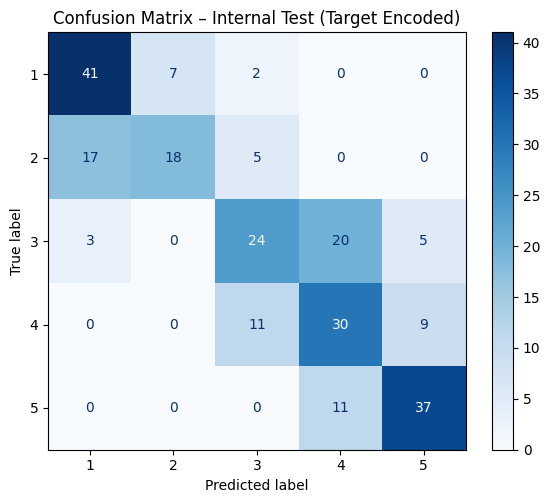

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix – Internal Test (Target Encoded)")
plt.tight_layout()
plt.show()


## Step 8 – Feature Importance: Original vs Encoded

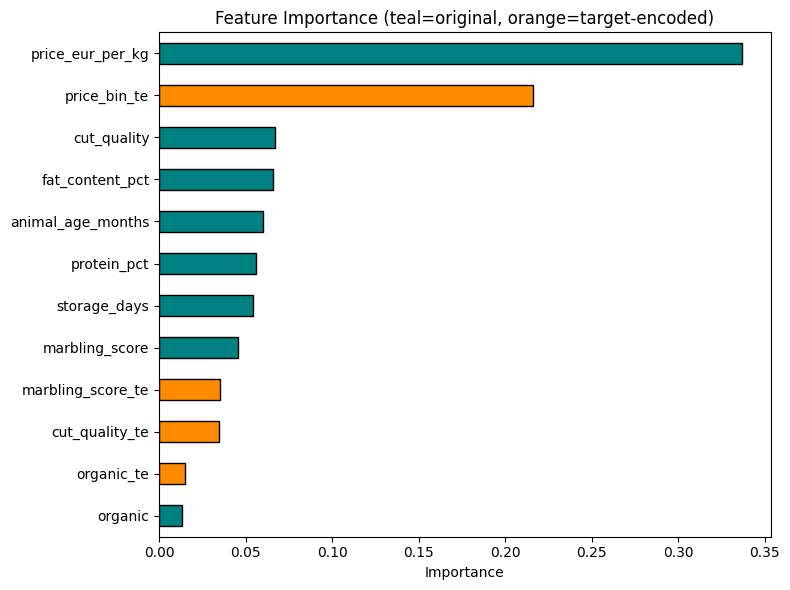

Importance values:
organic              0.0132
organic_te           0.0149
cut_quality_te       0.0345
marbling_score_te    0.0352
marbling_score       0.0457
storage_days         0.0544
protein_pct          0.0559
animal_age_months    0.0601
fat_content_pct      0.0660
cut_quality          0.0671
price_bin_te         0.2163
price_eur_per_kg     0.3366
dtype: float64
Original features total:  0.699
Encoded features total:   0.301


In [10]:
importances = pd.Series(rf_te.feature_importances_, index=feature_cols_te)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["darkorange" if "_te" in f else "teal" for f in importances.index]
importances.plot(kind="barh", ax=ax, color=colors, edgecolor="black")
ax.set_title("Feature Importance (teal=original, orange=target-encoded)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Importance values:")
print(importances.round(4))

# Sum importance by type
orig_imp = importances[[c for c in importances.index if "_te" not in c]].sum()
te_imp   = importances[[c for c in importances.index if "_te" in c]].sum()
print(f"Original features total:  {orig_imp:.3f}")
print(f"Encoded features total:   {te_imp:.3f}")


## Step 9 – Load and Impute Stress-Test Data (Domain-Based)

Using group-based imputation per meat_type, then apply the same
target encodings.


In [11]:
df_stress = pd.read_csv("meat_price_100_stress_test.csv")

print(f"Shape: {df_stress.shape}")
print(f"Missing values:{df_stress.isnull().sum()}")

# --- Domain-based imputation ---
X_stress = df_stress[feature_cols].copy()
y_stress = df_stress[target_col].copy()

# Build group medians from training data
group_medians = df.groupby(target_col).median()

# Fill feature NaN per meat_type group
for col in feature_cols:
    for mt in group_medians.index:
        mask = (y_stress == mt) & (X_stress[col].isnull())
        n = mask.sum()
        if n > 0:
            fill_val = group_medians.loc[mt, col]
            X_stress.loc[mask, col] = fill_val

# Fallback: rows where meat_type is NaN → global median
train_medians = X_train.median()
X_stress = X_stress.fillna(train_medians)

# Drop rows where target is NaN
valid_mask = y_stress.notna()
X_stress_valid = X_stress[valid_mask]
y_stress_valid = y_stress[valid_mask].astype(int)

print(f"Usable rows: {X_stress_valid.shape[0]} / {len(df_stress)}")
print(f"Remaining NaN: {X_stress_valid.isnull().sum().sum()}")


Shape: (100, 9)
Missing values:meat_type             9
fat_content_pct      14
protein_pct          10
marbling_score       11
animal_age_months     8
storage_days          9
organic               9
cut_quality           7
price_eur_per_kg      9
dtype: int64
Usable rows: 91 / 100
Remaining NaN: 0


## Step 10 – Apply Target Encoding to Stress-Test Data and Evaluate


In [12]:
# Apply same target encodings
X_stress_te = apply_target_encoding(X_stress_valid, encoding_maps, bin_edges)

# Predict
y_stress_pred = rf_te.predict(X_stress_te)

acc_stress = accuracy_score(y_stress_valid, y_stress_pred)
print(f"Stress-Test Accuracy: {acc_stress:.4f}")
print(classification_report(y_stress_valid, y_stress_pred, zero_division=0))


Stress-Test Accuracy: 0.2527
              precision    recall  f1-score   support

           1       0.50      0.11      0.18        18
           2       0.50      0.12      0.19        17
           3       0.05      0.08      0.06        12
           4       0.22      0.24      0.23        25
           5       0.32      0.63      0.43        19

    accuracy                           0.25        91
   macro avg       0.32      0.24      0.22        91
weighted avg       0.33      0.25      0.23        91



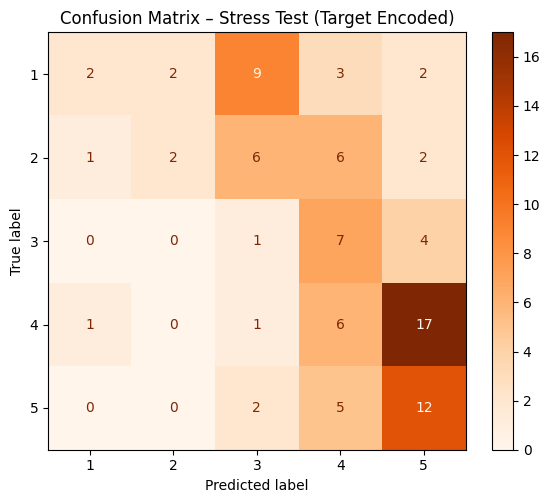

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_stress_valid, y_stress_pred, ax=ax, cmap="Oranges"
)
ax.set_title("Confusion Matrix – Stress Test (Target Encoded)")
plt.tight_layout()
plt.show()


## Step 11 – Full Comparison: All Classification Experiments


In [14]:
print("=" * 70)
print("CLASSIFICATION COMPARISON — All Experiments")
print("=" * 70)

comparison = pd.DataFrame({
    "Experiment": [
        "DT baseline (cut_quality target)",
        "DT baseline (meat_type target)",
        "DT + feature engineering",
        "RF baseline (KNN imputation)",
        "RF domain-based imputation",
        "RF + target encoding (this notebook)",
    ],
    "Acc Test": [
        "0.2250",
        "0.5292",
        "0.5292",
        "0.5625",
        "0.5625",
        f"{acc:.4f}",
    ],
    "Acc Stress": [
        "—",
        "0.2747",
        "0.2637",
        "0.2418",
        "0.2747",
        f"{acc_stress:.4f}",
    ],
})

print(comparison.to_string(index=False))
print("--- Done! ---")


CLASSIFICATION COMPARISON — All Experiments
                          Experiment Acc Test Acc Stress
    DT baseline (cut_quality target)   0.2250          —
      DT baseline (meat_type target)   0.5292     0.2747
            DT + feature engineering   0.5292     0.2637
        RF baseline (KNN imputation)   0.5625     0.2418
          RF domain-based imputation   0.5625     0.2747
RF + target encoding (this notebook)   0.6250     0.2527
--- Done! ---


In [ ]:
# next time xgb DT and RF are done in deepth